In [151]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(67)

def load_and_clean(filename):
    return np.loadtxt(filename, skiprows=2)

data_x = load_and_clean('x24x24.txt')
data_y = load_and_clean('y24x24.txt')
data_z = load_and_clean('z24x24.txt')
full_data = np.vstack([data_x, data_y, data_z])

X = full_data[:, :576]
y = full_data[:, 578]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.20,
    random_state=67,
    stratify=y           # photos of a person will be in both sets
)

In [152]:
unique_classes, counts = np.unique(y_train, return_counts=True)
df_init = pd.DataFrame({'class':unique_classes, 'count':counts})
min_count = counts.min()
min_count

np.int64(58)

Text(0.5, 0, 'class name')

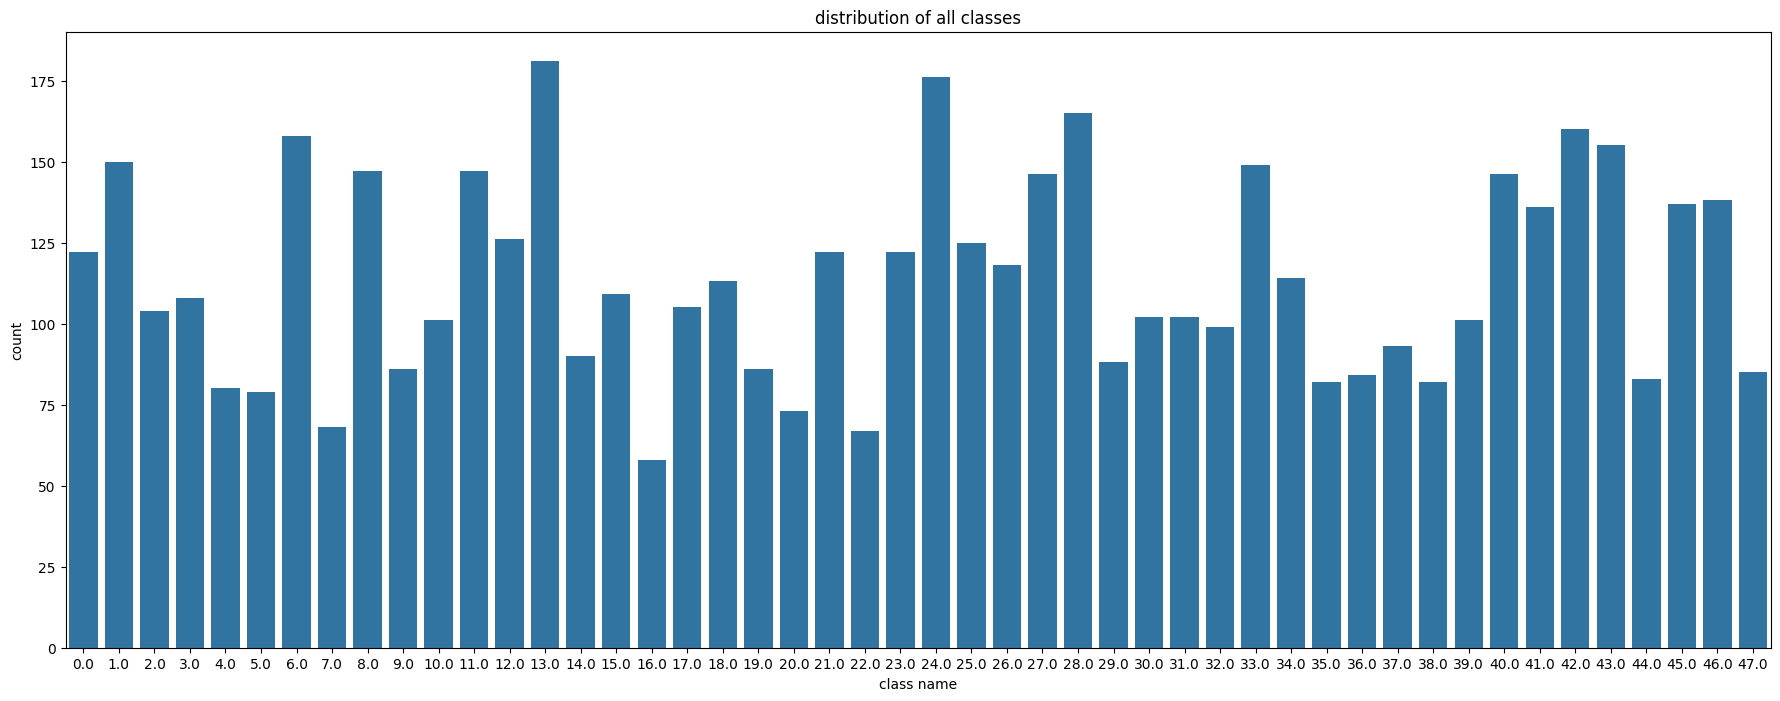

In [153]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(22,8))
sns.barplot(data=df_init, x='class', y='count')
plt.title("distribution of all classes")
plt.xlabel('class name')

In [154]:
# balanced_indexes = []
# for el in unique_classes:
#     found_el = np.where(y_train == el)[0]
#     random_selected = rng.choice(found_el, min_count, replace=False)
#     balanced_indexes.extend(random_selected)

# balanced_indexes = np.array(balanced_indexes)
# rng.shuffle(balanced_indexes)
# X_train = X_train[balanced_indexes]
# y_train = y_train[balanced_indexes]

In [155]:
# unique_balanced, balanced = np.unique(y_train, return_counts=True)
# df = pd.DataFrame({'class':unique_balanced, 'count':balanced})

In [156]:
# import seaborn as sns
# import matplotlib.pyplot as plt
# plt.figure(figsize=(22,8))
# sns.barplot(data=df, x='class', y='count')
# plt.title("distribution of all classes after balancing data")
# plt.xlabel('class name')

In [157]:
from sklearn.decomposition import PCA

# Redukcja wymiarów z 576 do 50 najważniejszych składowych
pca = PCA(n_components=60, random_state=67)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)

# Trenuj AdaBoost na X_train_pca - będzie błyskawiczny


In [ ]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

weak_learner = DecisionTreeClassifier(max_depth=10)
n_estimators = 400

adaboost_clf = AdaBoostClassifier(
    estimator=weak_learner,
    n_estimators=n_estimators,
    random_state=67,
    learning_rate=0.1
).fit(X_train_pca, y_train)


In [159]:
y_pred=adaboost_clf.predict(X_val_pca)

In [160]:
y_pred

In [161]:
# correct_predictions = [y_val[i] == y_pred[i] for i in range(len(y_pred))]

accuracy = np.mean(y_pred==y_val)
accuracy

np.float64(0.6305779078273592)

In [162]:
from sklearn.metrics import classification_report

print(classification_report(y_val, y_pred))

              precision    recall  f1-score   support

         0.0       0.83      0.61      0.70        31
         1.0       0.58      0.47      0.52        38
         2.0       0.77      0.65      0.71        26
         3.0       0.64      0.52      0.57        27
         4.0       0.90      0.45      0.60        20
         5.0       0.80      0.40      0.53        20
         6.0       0.54      0.75      0.62        40
         7.0       0.45      0.53      0.49        17
         8.0       0.76      0.78      0.77        37
         9.0       1.00      0.57      0.73        21
        10.0       0.71      0.48      0.57        25
        11.0       0.68      0.73      0.70        37
        12.0       0.43      0.65      0.51        31
        13.0       0.48      0.80      0.60        45
        14.0       0.81      0.74      0.77        23
        15.0       0.41      0.59      0.48        27
        16.0       0.78      0.47      0.58        15
        17.0       0.30    

Text(0.5, 0, 'class name')

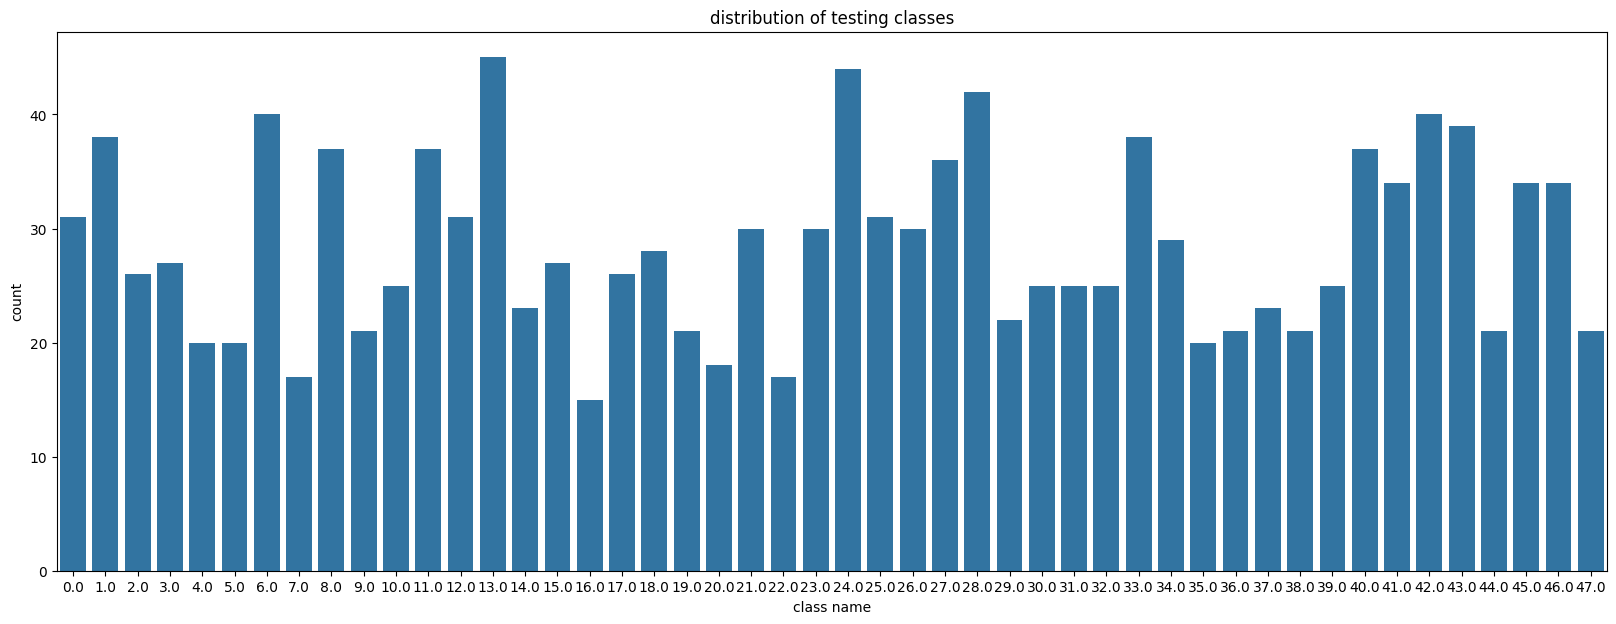

In [163]:
plt.figure(figsize=(20,7))
sns.countplot(x=y_val)
plt.title("distribution of testing classes")
plt.xlabel('class name')

Text(0.5, 0, 'class name')

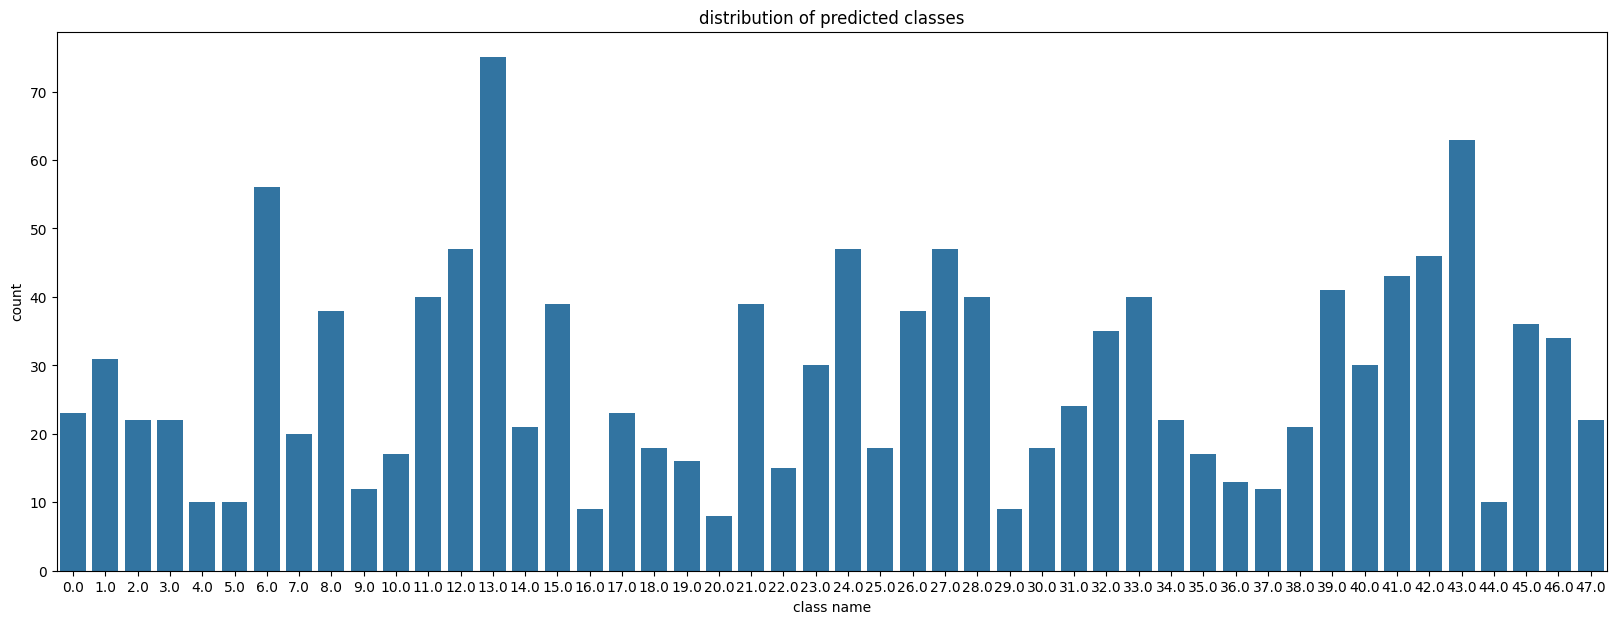

In [164]:
plt.figure(figsize=(20,7))
sns.countplot(x=y_pred)
plt.title("distribution of predicted classes")
plt.xlabel('class name')